## Check if the packages are installed

In [12]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")

pandas is installed
matplotlib is installed
numpy is installed


## Import Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import os
from sklearn.decomposition import PCA

from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import tensorflow as tf


## Load dataset

In [2]:
file_directory = "./Cleaned_Data"

# Load dataset from a CSV file
df = pd.read_csv(os.path.join(file_directory,"Cleaned_Data.csv"))

df = df.drop(columns = ['Unnamed: 0'])

# Display the first few rows of the dataset
df.head()

original_df = df

X = original_df.drop(['NLOS'], axis=1)
y = original_df['NLOS']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
X_test_pca = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])



## Visualization

c:\Users\triam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


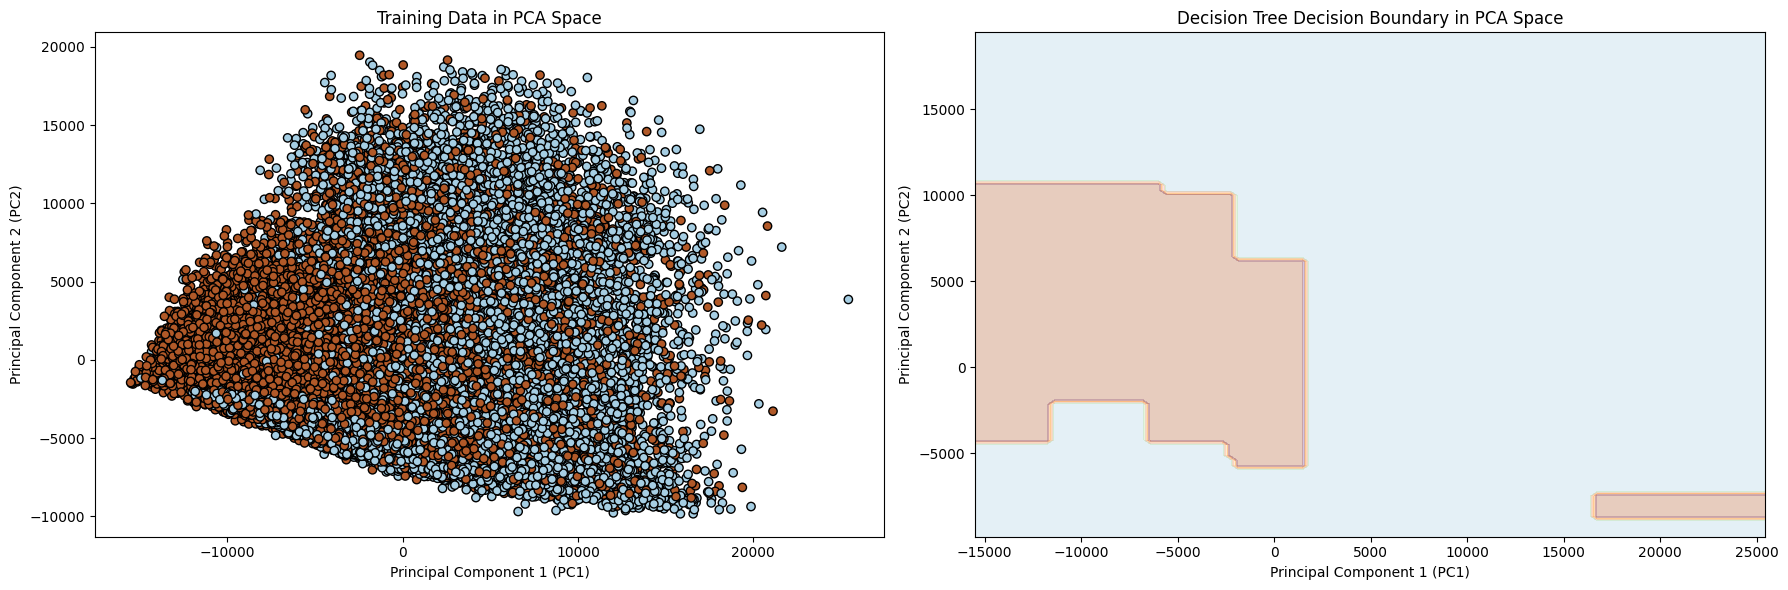

In [15]:
# Train Decision Tree on PCA-reduced features
dtc_pca = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dtc_pca.fit(X_train_pca, y_train)

# Create mesh grid for decision boundary visualization
x_min, x_max = X_train_pca["PC1"].min() - 1, X_train_pca["PC1"].max() + 1
y_min, y_max = X_train_pca["PC2"].min() - 1, X_train_pca["PC2"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict on mesh grid
Z = dtc_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Create a figure with 1 row and 2 columns (side by side)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Training Data
axes[0].scatter(X_train_pca["PC1"], X_train_pca["PC2"], c=y_train, edgecolor="k", cmap=plt.cm.Paired)
axes[0].set_xlabel("Principal Component 1 (PC1)")
axes[0].set_ylabel("Principal Component 2 (PC2)")
axes[0].set_title("Training Data in PCA Space")

# Plot 2: Decision Boundary
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
axes[1].set_xlabel("Principal Component 1 (PC1)")
axes[1].set_ylabel("Principal Component 2 (PC2)")
axes[1].set_title("Decision Tree Decision Boundary in PCA Space")

# Display the plots
plt.tight_layout()
plt.show()

c:\Users\triam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


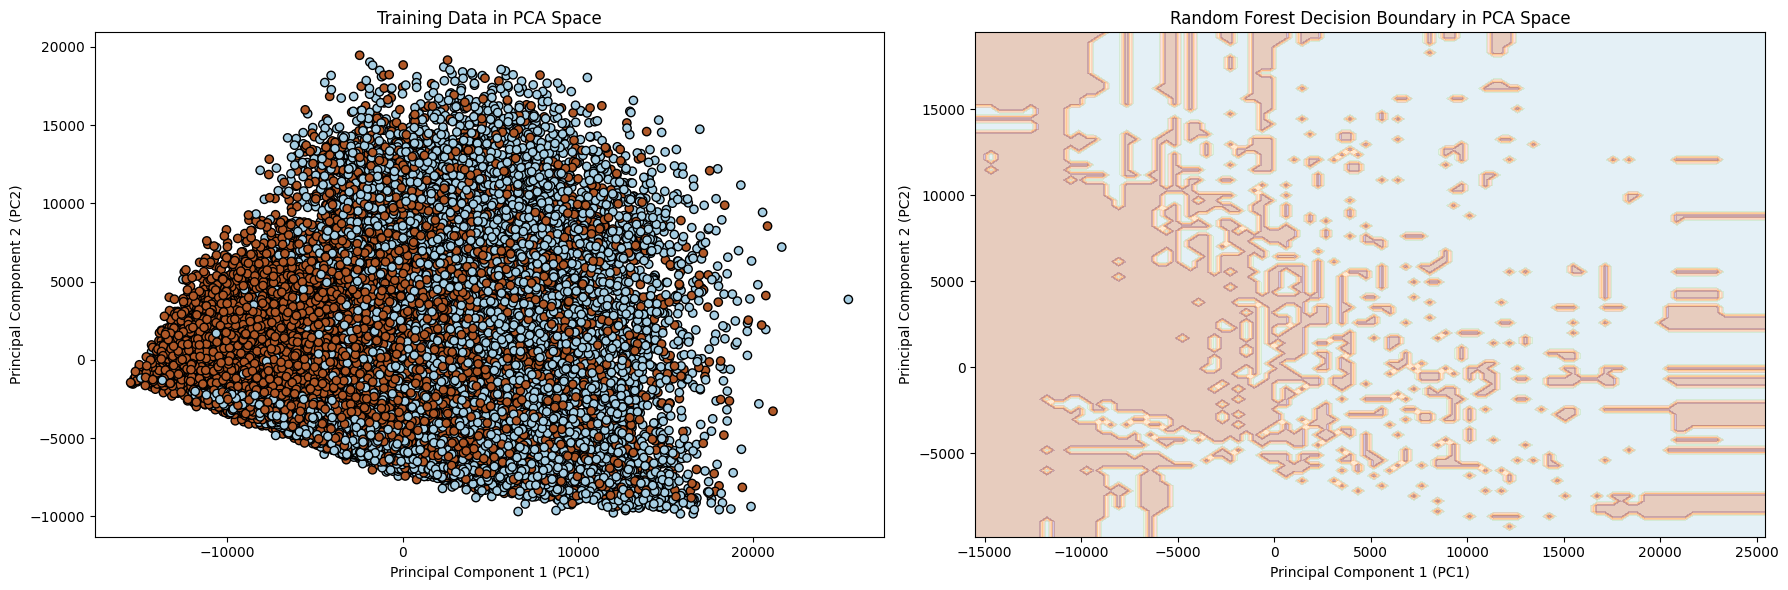

In [16]:
# Train Random Forest on PCA-reduced features
rfc_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_pca.fit(X_train_pca, y_train)

# Create mesh grid for decision boundary visualization
x_min, x_max = X_train_pca["PC1"].min() - 1, X_train_pca["PC1"].max() + 1
y_min, y_max = X_train_pca["PC2"].min() - 1, X_train_pca["PC2"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict on mesh grid
Z = rfc_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Create a figure with 1 row and 2 columns (side by side)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Training Data
axes[0].scatter(X_train_pca["PC1"], X_train_pca["PC2"], c=y_train, edgecolor="k", cmap=plt.cm.Paired)
axes[0].set_xlabel("Principal Component 1 (PC1)")
axes[0].set_ylabel("Principal Component 2 (PC2)")
axes[0].set_title("Training Data in PCA Space")


# Plot 2: Decision Boundary 
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
axes[1].set_xlabel("Principal Component 1 (PC1)")
axes[1].set_ylabel("Principal Component 2 (PC2)")
axes[1].set_title("Random Forest Decision Boundary in PCA Space")

# Display the plots
plt.tight_layout()
plt.show()


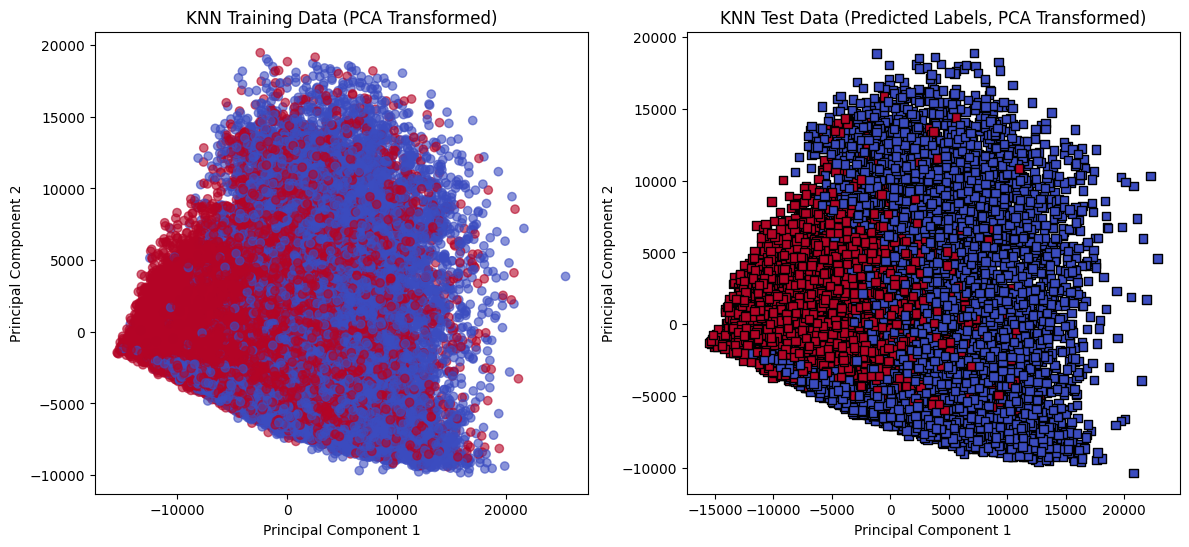

In [20]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
X_test_pca = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])

k_best = 10
clf_pca = KNeighborsClassifier(n_neighbors=k_best)
# Train the model on the training data
clf_pca.fit(X_train_pca, y_train)
# Make predictions using the trained model
y_pred_pca = clf_pca.predict(X_test_pca)

# Plot data for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_train_pca['PC1'], X_train_pca['PC2'], c=y_train, cmap='coolwarm', alpha=0.6)
axes[0].set_title("KNN Training Data (PCA Transformed)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

scatter = axes[1].scatter(X_test_pca['PC1'], X_test_pca['PC2'], c=y_pred_pca, cmap='coolwarm', edgecolor='black', marker='s')
axes[1].set_title("KNN Test Data (Predicted Labels, PCA Transformed)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.show()

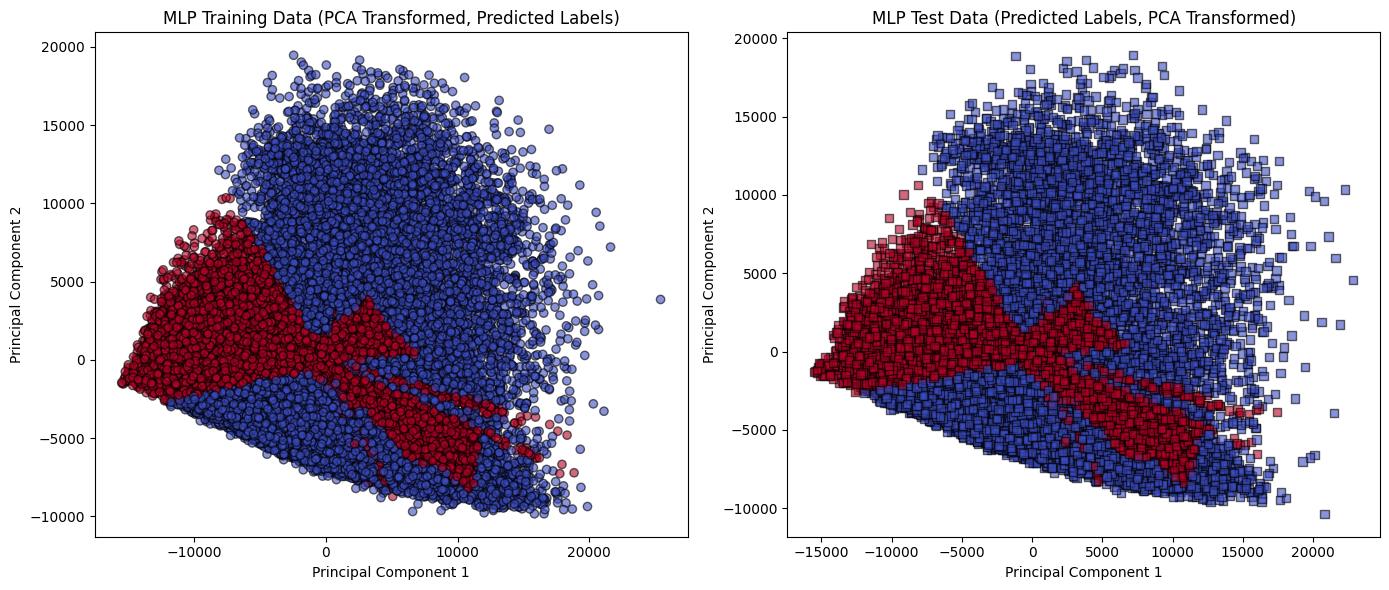

MLPClassifier (hidden_layer_sizes=(10, 10, 10)), Training Accuracy: 0.6338, Test Accuracy: 0.6357


In [21]:
# Initialize and train MLPClassifier
clf6 = MLPClassifier(solver='adam', hidden_layer_sizes=(10, 10, 10), learning_rate='adaptive', random_state=1, max_iter=1000)
clf6.fit(X_train_pca, y_train)

# Make predictions on training and test data
Y_predTrain = clf6.predict(X_train_pca)
Y_predTest = clf6.predict(X_test_pca)

# Append accuracy scores
trainAcc = accuracy_score(y_train, Y_predTrain)
testAcc = accuracy_score(y_test, Y_predTest)

# Create a figure with 1 row and 2 columns (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Training Data with Predicted Labels
axes[0].scatter(X_train_pca['PC1'], X_train_pca['PC2'], c=Y_predTrain, cmap='coolwarm', alpha=0.6, edgecolor='k')
axes[0].set_title("MLP Training Data (PCA Transformed, Predicted Labels)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# Plot 2: Test Data with Predicted Labels
axes[1].scatter(X_test_pca['PC1'], X_test_pca['PC2'], c=Y_predTest, cmap='coolwarm', alpha=0.6, edgecolor='k', marker='s')
axes[1].set_title("MLP Test Data (Predicted Labels, PCA Transformed)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

# Display the plots
plt.tight_layout()
plt.show()

# Print accuracy values
print(f'MLPClassifier (hidden_layer_sizes={(10, 10, 10)}), Training Accuracy: {trainAcc:.4f}, Test Accuracy: {testAcc:.4f}')
plt.show()

# Range Prediction

## Loading Test and Train Data

In [7]:
file_directory = "./Cleaned_Data"
# Load dataset from a CSV file
original_df_range = pd.read_csv(os.path.join(file_directory,"Range_Cleaned_Data.csv"))

X = original_df_range.drop(['RANGE'], axis=1)
y = original_df_range['RANGE']

# Split the dataset into training and testing sets
X_train_range, X_test_range, y_train_range, y_test_range = train_test_split(X, y, test_size=0.3, random_state=42)

## Linear Regressor Visualisation

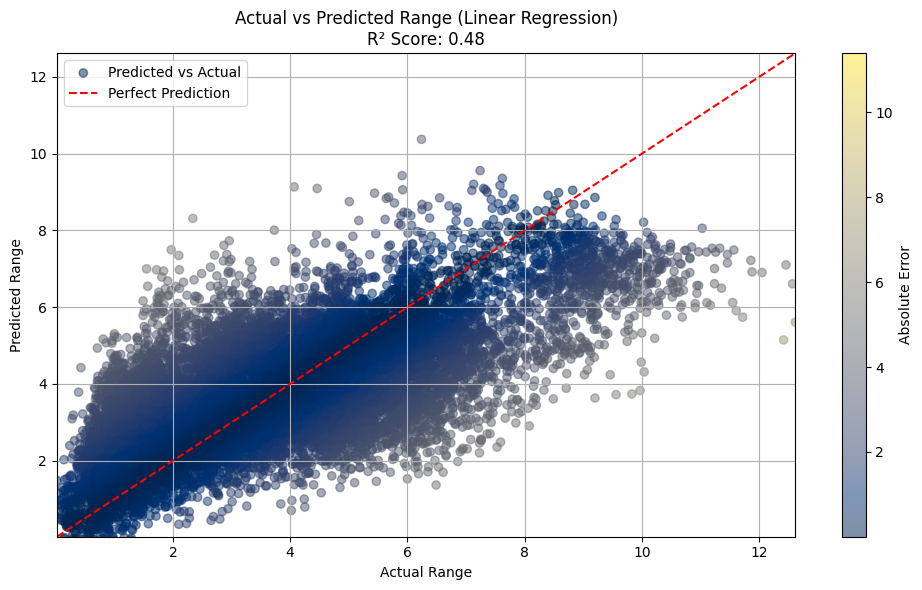

In [8]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

regr = linear_model.LinearRegression()
# Train the model on the training data
regr.fit(X_train_range, y_train_range)

# Make predictions using the trained model
y_pred_range = regr.predict(X_test_range)

# Compute R² and errors
r2_linreg = r2_score(y_test_range, y_pred_range)
errors_linreg = np.abs(y_test_range - y_pred_range)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    y_test_range,
    y_pred_range,
    c=errors_linreg,
    cmap='cividis',
    alpha=0.5,
    label='Predicted vs Actual'
)

# Perfect prediction line
# Plot data for visualization
plt.plot(
    [min(y_test_range), max(y_test_range)],
    [min(y_test_range), max(y_test_range)],
    color='red',
    linestyle='--',
    label="Perfect Prediction"
)

# Labels and Title
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title(f"Actual vs Predicted Range (Linear Regression)\nR² Score: {r2_linreg:.2f}")

# Axes range
plt.xlim(min(y_test_range), max(y_test_range))
plt.ylim(min(y_test_range), max(y_test_range))

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Absolute Error')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Artificial Neural Network Visualisation

c:\Users\triam\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8369 - mean_absolute_error: 0.7129 - mean_squared_error: 0.8369 - val_loss: 0.4232 - val_mean_absolute_error: 0.5069 - val_mean_squared_error: 0.4232 - learning_rate: 0.0010
Epoch 2/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4766 - mean_absolute_error: 0.5451 - mean_squared_error: 0.4766 - val_loss: 0.3872 - val_mean_absolute_error: 0.4838 - val_mean_squared_error: 0.3872 - learning_rate: 0.0010
Epoch 3/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4323 - mean_absolute_error: 0.5159 - mean_squared_error: 0.4323 - val_loss: 0.3689 - val_mean_absolute_error: 0.4685 - val_mean_squared_error: 0.3689 - learning_rate: 0.0010
Epoch 4/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4147 - mean_absolute_error: 0.5027 - mean_squared_error: 0.4147 - val_loss: 0.3625 - val_mean_absolute_error: 0.4651 - val_mean_squared_error: 0.3625 - learning_rate: 0.0010
Epoch 5/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

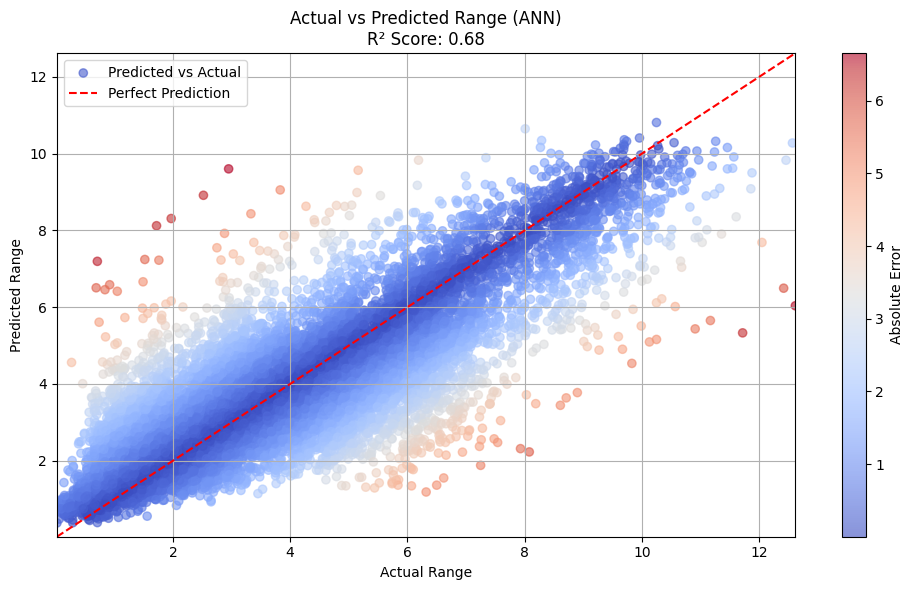

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- Data Scaling ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_range)
X_test_scaled = scaler_X.transform(X_test_range)

y_train_scaled = scaler_y.fit_transform(y_train_range.values.reshape(-1, 1)) 
y_test_scaled = scaler_y.transform(y_test_range.values.reshape(-1, 1))

# --- ANN Model Definition ---
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dense(1))  # Output layer

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mean_absolute_error', 'mean_squared_error'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

# Train the model on the training data
history = model.fit(X_train_scaled, y_train_scaled,
                    batch_size=32,
                    epochs=100,
                    validation_data=(X_test_scaled, y_test_scaled),
                    shuffle=True,
                    callbacks=[early_stop, reduce_lr],
                    verbose=1)

# Make predictions using the trained model
y_test_pred_scaled = model.predict(X_test_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_true = scaler_y.inverse_transform(y_test_scaled)

# Compute R² and errors
r2_ann = r2_score(y_test_true, y_test_pred)
errors_ann = np.abs(y_test_true - y_test_pred)

# --- Plot Actual vs Predicted with Enhancements ---
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    y_test_true,
    y_test_pred,
    c=errors_ann,
    cmap='coolwarm',
    alpha=0.6,
    label='Predicted vs Actual'
)

# Plot data for visualization
plt.plot(
    [min(y_test_true), max(y_test_true)],
    [min(y_test_true), max(y_test_true)],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

# Labels and R² Title
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title(f"Actual vs Predicted Range (ANN)\nR² Score: {r2_ann:.2f}")

# Match axes
plt.xlim(min(y_test_true), max(y_test_true))
plt.ylim(min(y_test_true), max(y_test_true))

cbar = plt.colorbar(scatter)
cbar.set_label('Absolute Error')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Random Forest Regressor Visualistion

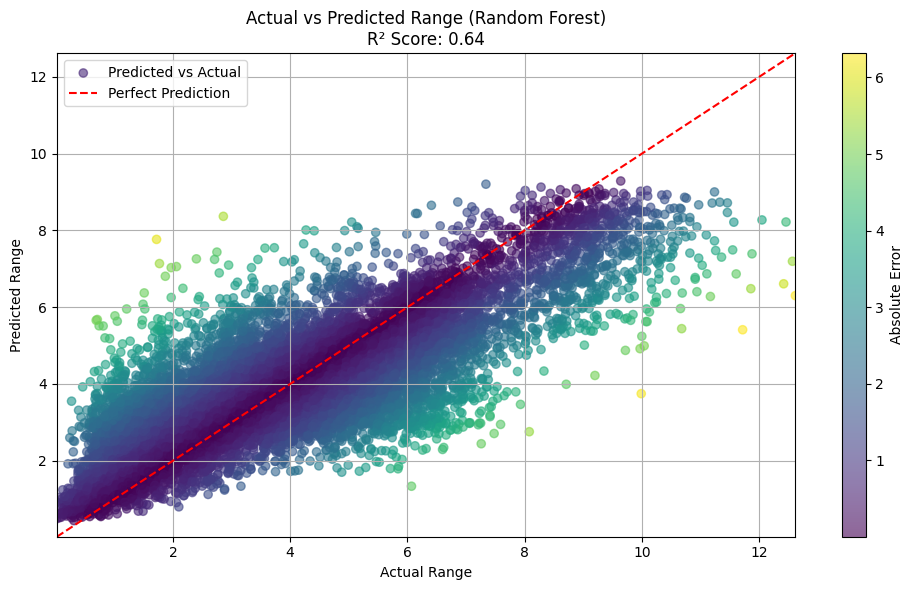

In [10]:
regressor = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=30,
    bootstrap=True,
    random_state=42
)
# Train the model on the training data
regressor.fit(X_train_range, y_train_range)

# Make predictions using the trained model
y_pred_range = regressor.predict(X_test_range)

# Compute R² and errors
r2 = r2_score(y_test_range, y_pred_range)
errors = np.abs(y_test_range - y_pred_range)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    y_test_range,
    y_pred_range,
    c=errors,
    cmap='viridis',
    alpha=0.6,
    label='Predicted vs Actual'
)

# Plot data for visualization
plt.plot(
    [min(y_test_range), max(y_test_range)],
    [min(y_test_range), max(y_test_range)],
    color='red',
    linestyle='--',
    label="Perfect Prediction"
)

# Labels and Title with R²
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title(f"Actual vs Predicted Range (Random Forest)\nR² Score: {r2:.2f}")

# Axis limits
plt.xlim(min(y_test_range), max(y_test_range))
plt.ylim(min(y_test_range), max(y_test_range))

cbar = plt.colorbar(scatter)
cbar.set_label('Absolute Error')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## XGBoost Regressor Visualisation

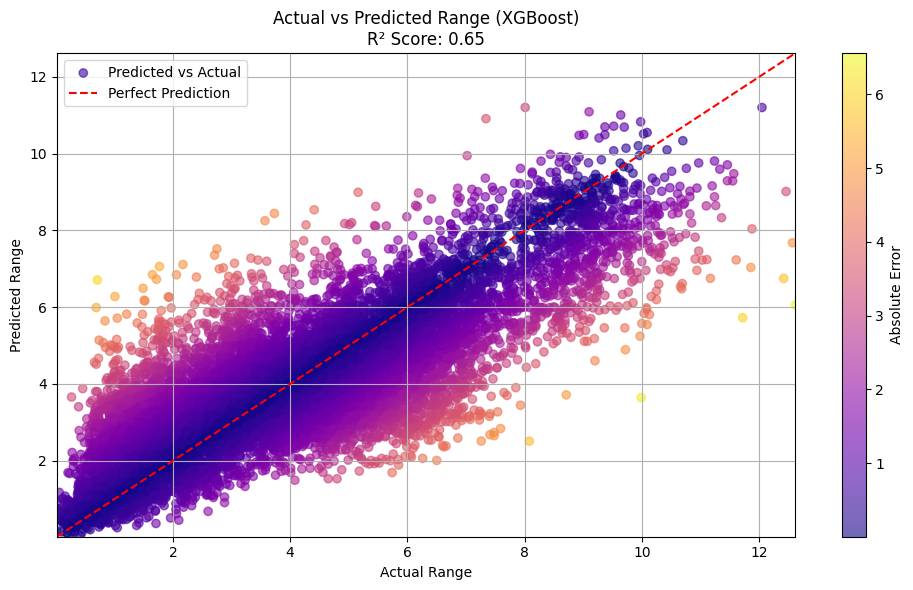

In [11]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
# Train the model on the training data
xgb_model.fit(X_train_range, y_train_range)

# Make predictions using the trained model
y_pred_xgb = xgb_model.predict(X_test_range)

# Evaluation
r2_xgb = r2_score(y_test_range, y_pred_xgb)
errors_xgb = np.abs(y_test_range - y_pred_xgb)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    y_test_range,
    y_pred_xgb,
    c=errors_xgb,
    cmap='plasma',
    alpha=0.6,
    label='Predicted vs Actual'
)

# Plot data for visualization
plt.plot(
    [min(y_test_range), max(y_test_range)],
    [min(y_test_range), max(y_test_range)],
    color='red',
    linestyle='--',
    label="Perfect Prediction"
)

# Labels and Title with R²
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title(f"Actual vs Predicted Range (XGBoost)\nR² Score: {r2_xgb:.2f}")

# Axis limits
plt.xlim(min(y_test_range), max(y_test_range))
plt.ylim(min(y_test_range), max(y_test_range))

cbar = plt.colorbar(scatter)
cbar.set_label('Absolute Error')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()